### AoC 2025 Day 11

In [1]:
lines = open('input11').readlines()
lines = [x.split(':') for x in lines]
graph: dict[str, list[str]] = {x[0]: x[1].strip().split(' ') for x in lines}
print('num lines:', len(graph))
list(graph.items())[:5]

num lines: 574


[('itg', ['wvf', 'rvk']),
 ('edd', ['axa']),
 ('feu', ['fdq', 'ilp', 'zkh']),
 ('skm', ['otb', 'wsh']),
 ('qdc', ['bpy', 'zyd'])]

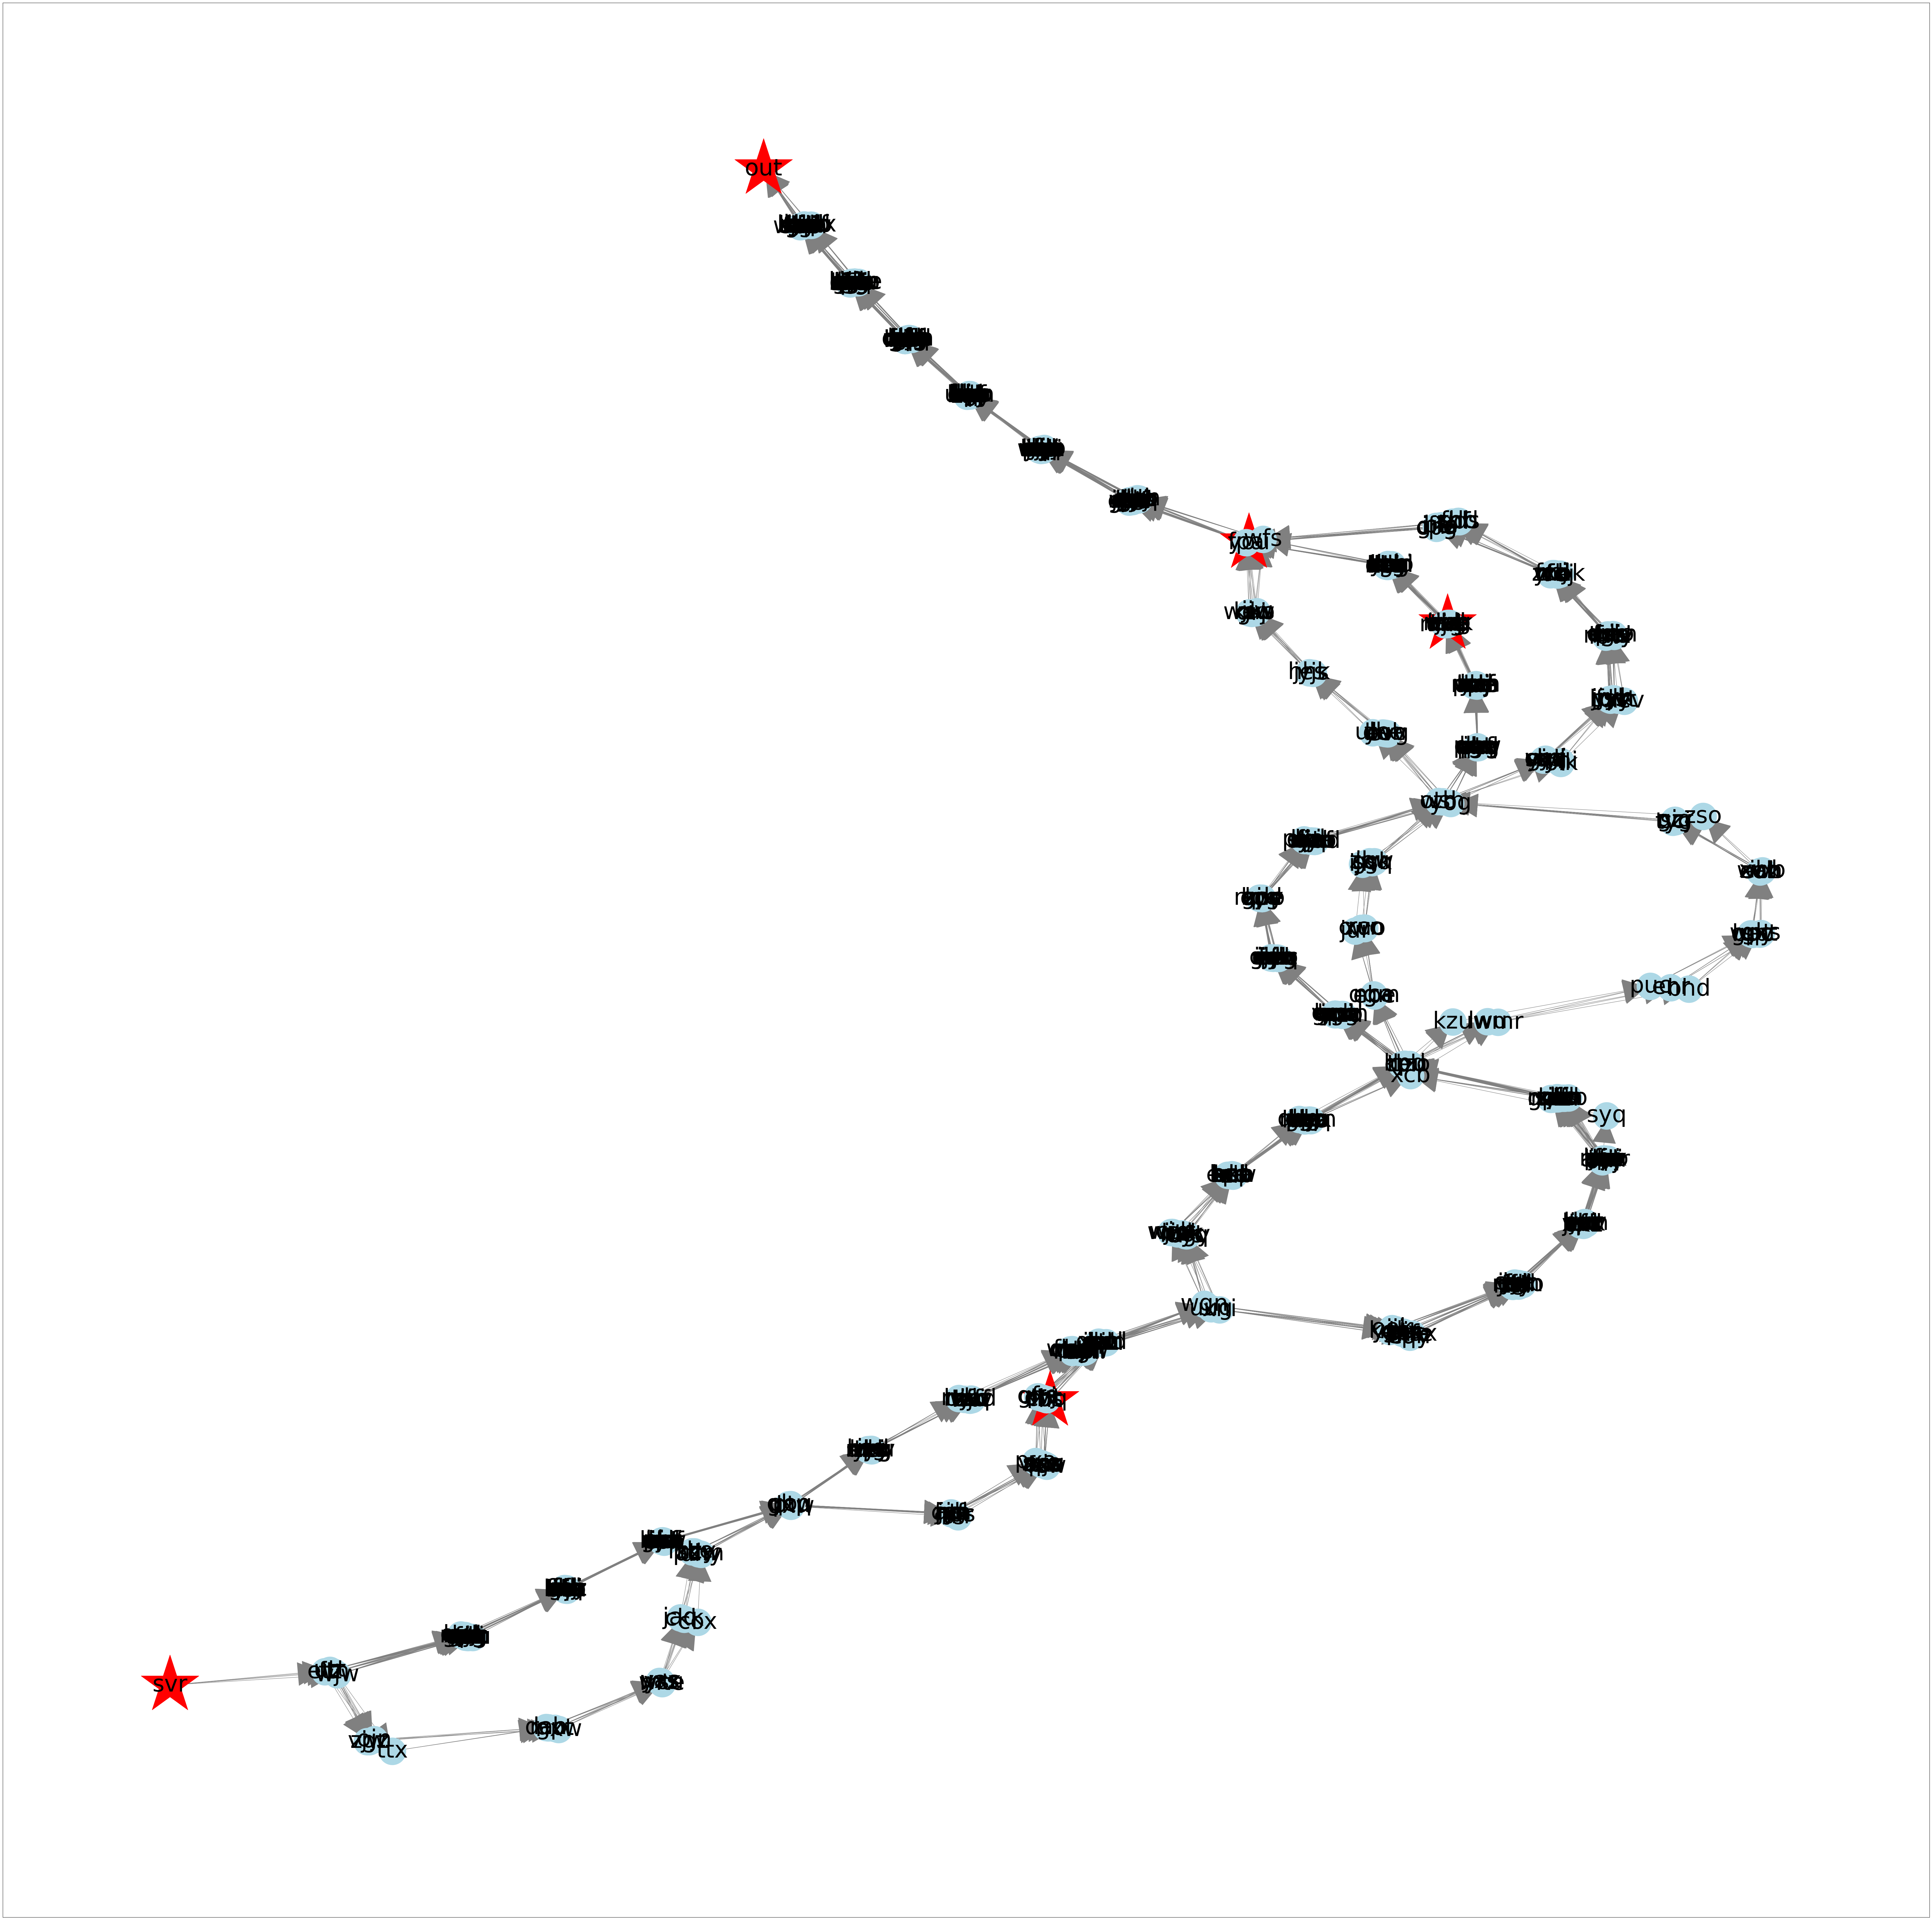

In [2]:
# Plotting the graph
# !pip install networkx
import networkx as nx
import matplotlib.pyplot as plt

G = nx.DiGraph()
for node, neighbors in graph.items():
    for n in neighbors:
        G.add_edge(node, n)

color_map = ['red' if n in ('you','svr','dac','fft','out') else 'lightblue' for n in G.nodes()]
plt.figure(figsize=(90, 90))
pos = nx.kamada_kawai_layout(G)
special = {'you', 'svr', 'dac', 'fft', 'out'}
nx.draw_networkx_nodes(G, pos, nodelist=[n for n in G if n in special], node_shape='*', node_size=25000, node_color='red')
nx.draw_networkx_nodes(G, pos, nodelist=[n for n in G if n not in special], node_shape='o', node_size=5000, node_color='lightblue')
nx.draw_networkx_edges(G, pos, edge_color='gray', arrows=True, arrowsize=150)
nx.draw_networkx_labels(G, pos, font_size=60)
plt.show()

#### Part 1
number of unique paths `you` -> `out`

In [3]:
from functools import cache

@cache
def num_paths(start_node: str, end_node: str) -> int:
    return 1 if start_node == end_node else sum(num_paths(n, end_node) for n in graph.get(start_node, []))

print('Part 1:', num_paths('you', 'out'))

Part 1: 753


#### Part 2
number of unique paths, either <br>
`svr` -> `dac` -> `fft` -> `out` <br>
`svr` -> `fft` -> `dac` -> `out`

In [4]:
part2 = (num_paths('svr', 'dac') * num_paths('dac', 'fft') * num_paths('fft', 'out') + 
         num_paths('svr', 'fft') * num_paths('fft', 'dac') * num_paths('dac', 'out'))
print('Part 2:', part2)

Part 2: 450854305019580
